In [ ]:
from google.colab import files
uploaded = files.upload()

Saving synthetic_cybersecurity_dataset_v2.csv to synthetic_cybersecurity_dataset_v2.csv


Dataset loaded. Shape: (1000, 11)
Label distribution:
 Label
0    809
1    191
Name: count, dtype: int64
Sequence shape: (990, 10, 9)
Target shape: (990,)
Train shape: (792, 10, 9)
Test shape: (198, 10, 9)
Test label distribution: [160  38]


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,001 (78.13 KB)

 Trainable params: 20,001 (78.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 119ms/step - accuracy: 0.5979 - loss: 0.9595 - val_accuracy: 0.7925 - val_loss: 0.6313
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.8181 - loss: 0.9086 - val_accuracy: 0.7925 - val_loss: 0.6204
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8170 - loss: 0.9060 - val_accuracy: 0.7925 - val_loss: 0.6158
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8283 - loss: 0.8851 - val_accuracy: 0.7925 - val_loss: 0.6024
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7926 - loss: 0.9639 - val_accuracy: 0.7925 - val_loss: 0.6274
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7923 - loss: 0.9558 - val_accuracy: 0.7925 - val_loss: 0.6045
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8287 - loss: 0.8747 - val_accuracy: 0.7673 - val_loss: 0.6731
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7891 - loss: 0.9034 - val_accuracy: 0.7925 -

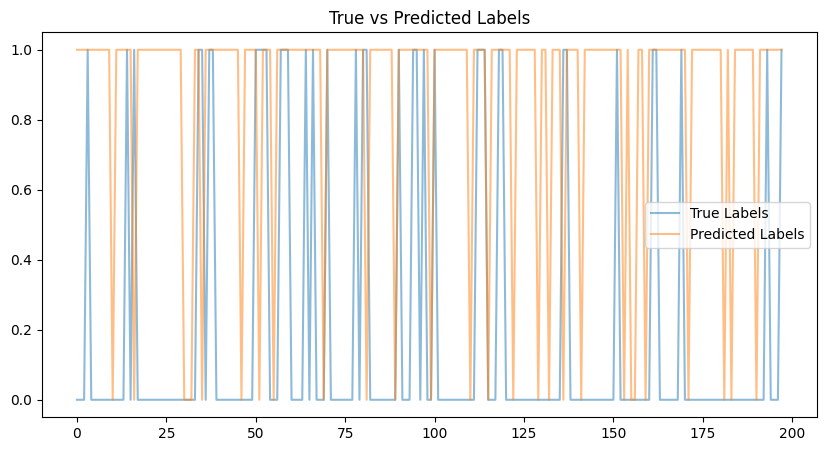

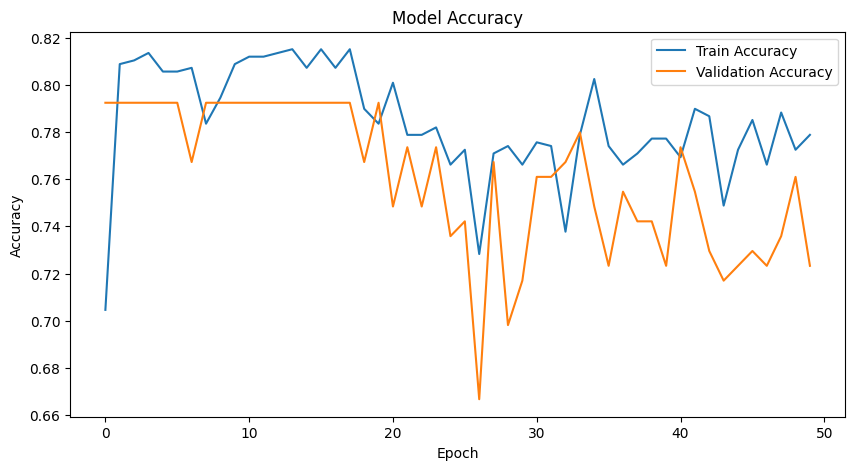

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt


timesteps = 10
features = 9
test_size = 0.2
random_seed = 42





df = pd.read_csv("synthetic_cybersecurity_dataset_v2.csv")
print("Dataset loaded. Shape:", df.shape)
print("Label distribution:\n", df["Label"].value_counts())




feature_cols = ["Flow_Duration", "Total_Fwd_Packets", "Total_Backward_Packets",
                "Total_Length_of_Fwd_Packets", "Total_Length_of_Bwd_Packets",
                "Fwd_Packet_Length_Mean", "Bwd_Packet_Length_Mean",
                "Flow_Bytes_Per_Second", "Flow_Packets_Per_Second"]
X = df[feature_cols].values
y = df["Label"].values



scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

def create_sequences(X, y, timesteps):
    X_seq, y_seq = [], []
    for i in range(len(X) - timesteps):
        X_seq.append(X[i:i + timesteps])
        y_seq.append(y[i + timesteps])
    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = create_sequences(X_scaled, y, timesteps)
print("Sequence shape:", X_seq.shape)


print("Target shape:", y_seq.shape)

X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=test_size,
                                                    random_state=random_seed, shuffle=True,
                                                    stratify=y_seq)
print("Train shape:", X_train.shape)

print("Test shape:", X_test.shape)
print("Test label distribution:", np.bincount(y_test))



class_weights = {0: 1.0, 1: 3.0}

model = Sequential()
model.add(LSTM(units=64, input_shape=(timesteps, features), return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(16, activation="relu"))
model.add(Dropout(0.2))


model.add(Dense(1, activation="sigmoid"))
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()


history = model.fit(X_train, y_train, epochs=50, batch_size=32,
                    validation_split=0.2, class_weight=class_weights, verbose=1)

y_pred_prob = model.predict(X_test).flatten()




y_pred = (y_pred_prob > 0.3).astype(int)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("Prediction probabilities (first 10):", y_pred_prob[:10])

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred_prob)
mae = mean_absolute_error(y_test, y_pred_prob)

print("\nEvaluation Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(y_test, label="True Labels", alpha=0.5)
plt.plot(y_pred, label="Predicted Labels", alpha=0.5)
plt.title("True vs Predicted Labels")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()